<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_3_Interactions/17_3_1_MedicalCost_Interactions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Beyond Additive Models
## Interaction Effects in Medical Costs

Every regression model we have built so far has made the same quiet assumption: each feature contributes its effect *independently*, and the prediction is just the sum of those contributions. Add a bedroom, price goes up by so much. Add a square foot, price goes up by so much more. The features never talk to each other.

In the Ames notebooks, when the model wasn't good enough, our instinct was to add more columns. This notebook is about a different — and often more powerful — move: keeping the same columns but letting the effect of one feature *depend on* another. That is an **interaction effect**, and once you know what one looks like, you will start seeing them everywhere.

Our case study: 1,338 medical insurance customers. We want to predict annual medical charges. Two of the features are body mass index (`bmi`) and whether the person smokes (`smoker`). The question that drives the whole notebook: **is a point of BMI worth the same number of dollars for a smoker as for a non-smoker?**

## 1. The Data

Each row is one insurance customer: age, sex, BMI, number of children, smoking status, region, and the target — `charges`, their annual medical costs in dollars.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols

url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

print(df.shape)
df.head()

(1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. See It Before You Model It

Before fitting anything, let's plot `charges` against `bmi` — but with one twist: we color the points by smoking status and let seaborn fit a separate regression line for each group. If BMI affected everyone's costs the same way, the two lines would be roughly parallel.

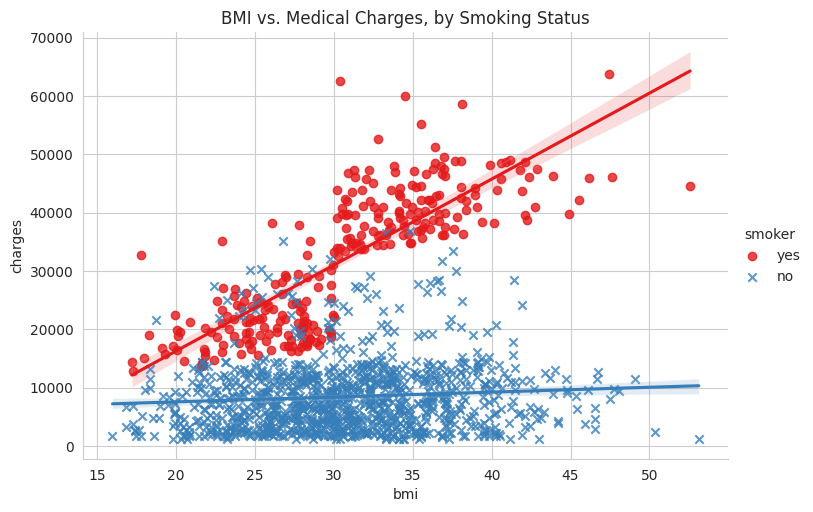

In [2]:
sns.set_style('whitegrid')
sns.lmplot(x="bmi", y="charges", hue="smoker", data=df,
           aspect=1.5, markers=["o", "x"], palette="Set1")
plt.title("BMI vs. Medical Charges, by Smoking Status")
plt.show()

The two lines are nowhere near parallel. For non-smokers (the flat line), an extra point of BMI barely moves predicted charges at all. For smokers, the line climbs steeply — every additional point of BMI is associated with substantially higher costs.

This is what an interaction looks like in a picture: **the slope of one variable changes depending on the value of another.** No amount of shifting a single line up or down can capture two different slopes. Let's watch a model fail at exactly this.

## 3. The Additive Model

First, the model we already know how to build: `charges ~ bmi + smoker`. "Additive" means the model gets one slope for BMI and one vertical offset for smokers. In the picture, that is two *parallel* lines — the smoker line is shifted up, but both lines are forced to share the same slope.

In [3]:
model_additive = ols('charges ~ bmi + smoker', data=df).fit()

print("--- ADDITIVE MODEL (charges ~ bmi + smoker) ---")
print(f"R-squared: {model_additive.rsquared:.4f}")
print(f"AIC:       {model_additive.aic:.2f}")
print()
print(model_additive.params)

--- ADDITIVE MODEL (charges ~ bmi + smoker) ---
R-squared: 0.6579
AIC:       27525.89

Intercept        -3459.095521
smoker[T.yes]    23593.980999
bmi                388.015246
dtype: float64


Not a terrible model — smoking status alone carries a lot of information, so $R^2$ is already respectable. But look at what it claims: one shared `bmi` slope of about \$388 per BMI point, applied to smokers and non-smokers alike. The scatterplot just told us that's a compromise between a nearly-flat line and a steep one — a slope that is wrong for *everyone*.

## 4. Letting the Slope Change: the Interaction Model

To let the BMI slope differ by smoking status, we add an **interaction term**. In a statsmodels formula, `bmi * smoker` is shorthand that expands to three terms:

$$\texttt{charges} \sim \underbrace{\texttt{bmi}}_{\text{main effect}} + \underbrace{\texttt{smoker}}_{\text{main effect}} + \underbrace{\texttt{bmi:smoker}}_{\text{interaction}}$$

The colon term `bmi:smoker` is literally a new feature — the product of the two columns — and its coefficient measures how much the BMI slope *changes* when `smoker` flips from no to yes. Use `*` rather than typing the three terms yourself: it guarantees the main effects always ride along with the interaction. (An interaction without its main effects is almost never what you want — the coefficients become nearly impossible to interpret.)

In [4]:
model_interaction = ols('charges ~ bmi * smoker', data=df).fit()

print("--- INTERACTION MODEL (charges ~ bmi * smoker) ---")
print(f"R-squared: {model_interaction.rsquared:.4f}")
print(f"AIC:       {model_interaction.aic:.2f}")
print()
print(model_interaction.params)

--- INTERACTION MODEL (charges ~ bmi * smoker) ---
R-squared: 0.7418
AIC:       27151.73

Intercept             5879.424082
smoker[T.yes]       -19066.000405
bmi                     83.350558
bmi:smoker[T.yes]     1389.755697
dtype: float64


## 5. Reading the Coefficients

The coefficient table now tells a two-regime story. Reading each line in plain English:

- **`bmi` ≈ \$83.** This is now the slope for *non-smokers only* (the reference group). Each BMI point adds about \$83 for a non-smoker — almost nothing on the scale of these charges. That is the flat line from Section 2.
- **`bmi:smoker[T.yes]` ≈ \$1,390.** This is the *change in slope* for smokers. A smoker's per-BMI-point cost is the base slope plus this: roughly $83 + 1{,}390 \approx \$1{,}473$ per BMI point — nearly **18× steeper** than the non-smoker slope.
- **`smoker[T.yes]`** is large and *negative*, which surprises students every time. It is the gap between the two lines at $\texttt{bmi} = 0$ — a BMI no human has. Once lines have different slopes, their offset at zero stops being directly meaningful on its own; the slopes are where the story is.

And the model comparison agrees with the picture:

- $R^2$ jumps from about **0.66** to about **0.74** — a solid gain from a single added term.
- **AIC drops** substantially. AIC penalizes complexity, so this says the extra term more than earns its keep. (Remember: $R^2$ *always* rises when you add a term, so the jump alone proves little — AIC and the plot are what make the case.)

## 6. Why This Matters

In the Ames notebooks, the instinct when a model underperformed was "add more columns." This notebook shows the counter-move: **how variables relate to each other can matter more than how many you have.** One well-chosen interaction term — a feature we *engineered* by multiplying two existing columns — did more for this model than most new columns would.

The stakes are real, too. An insurance company pricing from the additive model would charge smokers and non-smokers the same rate per BMI point, quietly undercharging high-BMI smokers and overcharging everyone else. When a true interaction exists and your model omits it, the errors don't spread evenly — they concentrate on specific groups of people.

Where to look for interactions in your own data: whenever the mechanism suggests one variable *amplifies* another (dosage × body weight, advertising × season, education × experience), plot the slopes by group first — exactly as we did in Section 2 — and let the picture tell you whether the lines are parallel.